In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

**Loading The Data**

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images Shape:", x_train.shape)
print("Testing Images Shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
Training Images Shape: (50000, 32, 32, 3)
Testing Images Shape: (10000, 32, 32, 3)


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

Checking The Quality of Images

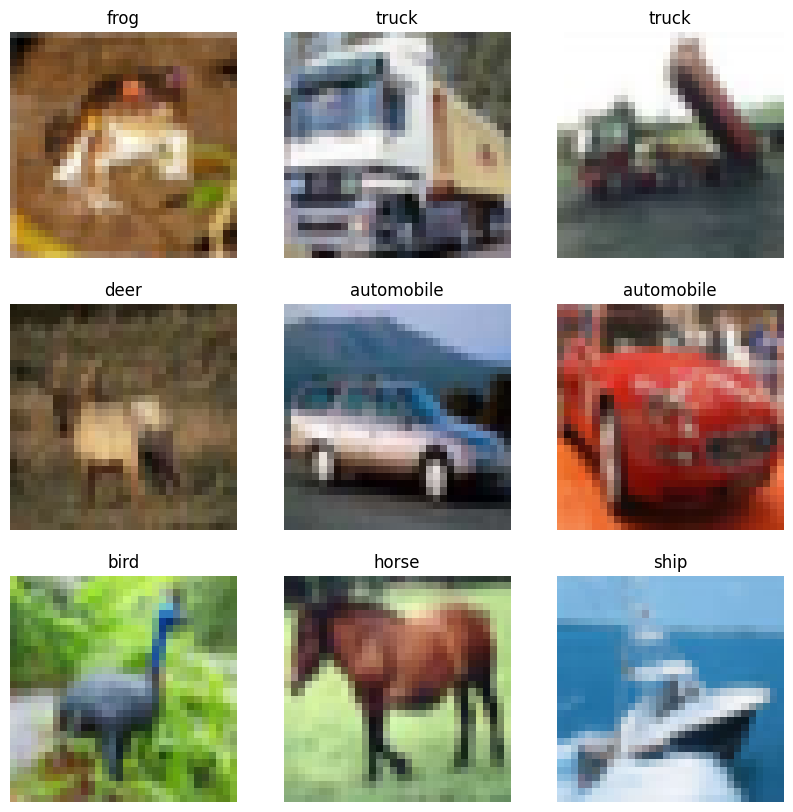

In [ ]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')

plt.show()

Base Model

In [5]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights=None
)

Custom Loss Function

In [6]:
penalty_matrix = np.ones((10, 10), dtype=np.float32)
vehicles = [0, 1, 8, 9]
animals = [2, 3, 4, 5, 6, 7]

for v in vehicles:
    for a in animals:
        penalty_matrix[v, a] = 3.0
        penalty_matrix[a, v] = 3.0

np.fill_diagonal(penalty_matrix, 0.0)
PENALTY_TENSOR = tf.constant(penalty_matrix)

def similarity_loss(y_true, y_pred):
    y_true_labels = tf.cast(tf.argmax(y_true, axis=-1), tf.int32)

    batch_penalties = tf.gather(PENALTY_TENSOR, y_true_labels)

    expected_cost = tf.reduce_sum(batch_penalties * y_pred, axis=-1)

    standard_cce = tf.keras.losses.sparse_categorical_crossentropy(y_true_labels, y_pred)

    total_loss = standard_cce + expected_cost

    return tf.reduce_mean(total_loss)


In [7]:
model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

Using In-Built Loss function

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 315s 393ms/step - accuracy: 0.2162 - loss: 2.0641 - val_accuracy: 0.0970 - val_loss: 2.3126
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 257s 364ms/step - accuracy: 0.3370 - loss: 1.7432 - val_accuracy: 0.0970 - val_loss: 2.3615
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 257s 357ms/step - accuracy: 0.4014 - loss: 1.6145 - val_accuracy: 0.0970 - val_loss: 2.3464
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 246s 349ms/step - accuracy: 0.4530 - loss: 1.5072 - val_accuracy: 0.0970 - val_loss: 2.3328
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 262s 350ms/step - accuracy: 0.4942 - loss: 1.4206 - val_accuracy: 0.1038 - val_loss: 2.3233
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 242s 344ms/step - accuracy: 0.5322 - loss: 1.3355 - val_accuracy: 0.1620 - val_loss: 2.2650
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 244s 347ms/step - accuracy: 0.5634 - loss: 1.2702 - val_accuracy: 0.4482 - val_loss: 1.7045
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 244s 346ms/step - accuracy: 0.5900 -


Evaluating Model on Test Data
313/313 - 13s - 42ms/step - accuracy: 0.4681 - loss: 5.7145

Test accuracy: 0.4681
Final Test Accuracy: 0.4681
Final Test Loss:     5.7145



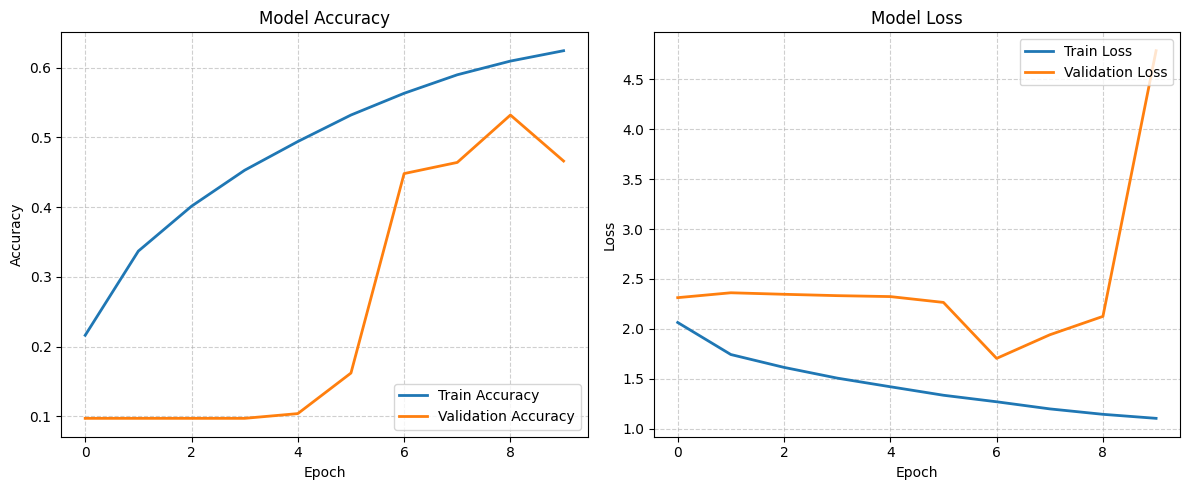

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Single Image Prediction
Predicted class: automobile (55.73% confidence)
Actual class:    airplane


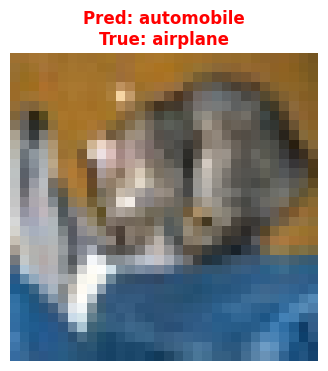

In [12]:
print("\nEvaluating Model on Test Data")

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss:     {test_loss:.4f}\n")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

#to test different images
image_index = 0

sample_image = x_test[image_index:image_index+1]


prediction_probs = model.predict(sample_image)[0]
predicted_class_idx = np.argmax(prediction_probs)

true_label = y_test[image_index]
actual_class_idx = int(true_label[0]) if isinstance(true_label, (np.ndarray, list)) else int(true_label)

#confidence percentage
print("\nSingle Image Prediction")
print(f"Predicted class: {class_names[predicted_class_idx]} ({prediction_probs[predicted_class_idx]*100:.2f}% confidence)")
print(f"Actual class:    {class_names[actual_class_idx]}")

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(sample_image[0])
plt.axis('off')

# Color the title green if correct, red if wrong
title_color = 'green' if predicted_class_idx == actual_class_idx else 'red'
plt.title(f"Pred: {class_names[predicted_class_idx]}\nTrue: {class_names[actual_class_idx]}", color=title_color, fontweight='bold')
plt.show()

Custom Loss Function 1

In [10]:
def lossFun(y_true, y_pred):
    y_true_labels = tf.cast(tf.argmax(y_true, axis=-1), tf.int32)


    standard_cce = tf.keras.losses.sparse_categorical_crossentropy(y_true_labels, y_pred)


    vehicle = tf.reduce_sum(tf.gather(y_pred, [0, 1, 8, 9], axis=1), axis=1)
    animal  = tf.reduce_sum(tf.gather(y_pred, [2, 3, 4, 5, 6, 7], axis=1), axis=1)


    super_y_pred = tf.stack([vehicle, animal], axis=1)

    mapping = tf.constant([0, 0, 1, 1, 1, 1, 1, 1, 0, 0], dtype=tf.int32)

    super_y_true = tf.gather(mapping, y_true_labels)

    super_loss = tf.keras.losses.sparse_categorical_crossentropy(super_y_true, super_y_pred)

    total_loss = standard_cce + (0.5 * super_loss)

    return tf.reduce_mean(total_loss)

In [14]:
model.compile(
    optimizer='adam',
    loss=lossFun,
    metrics=['accuracy']
)

In [15]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 286s 352ms/step - accuracy: 0.6480 - loss: 1.1275 - val_accuracy: 0.5716 - val_loss: 3.5563
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 262s 353ms/step - accuracy: 0.6663 - loss: 1.0668 - val_accuracy: 0.5450 - val_loss: 4.2263
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 260s 349ms/step - accuracy: 0.6818 - loss: 1.0157 - val_accuracy: 0.5978 - val_loss: 2.9986
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 246s 350ms/step - accuracy: 0.6995 - loss: 0.9602 - val_accuracy: 0.6404 - val_loss: 2.0509
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 244s 347ms/step - accuracy: 0.7070 - loss: 0.9341 - val_accuracy: 0.5676 - val_loss: 3.0986
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 246s 349ms/step - accuracy: 0.7015 - loss: 0.9474 - val_accuracy: 0.6158 - val_loss: 2.0018
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 244s 347ms/step - accuracy: 0.7131 - loss: 0.9083 - val_accuracy: 0.6584 - val_loss: 1.9436
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 244s 347ms/step - accuracy: 0.7450 -


Evaluating Model on Test Data
313/313 - 14s - 44ms/step - accuracy: 0.6385 - loss: 1.6207

Test accuracy: 0.6385
Final Test Accuracy: 0.6385
Final Test Loss:     1.6207



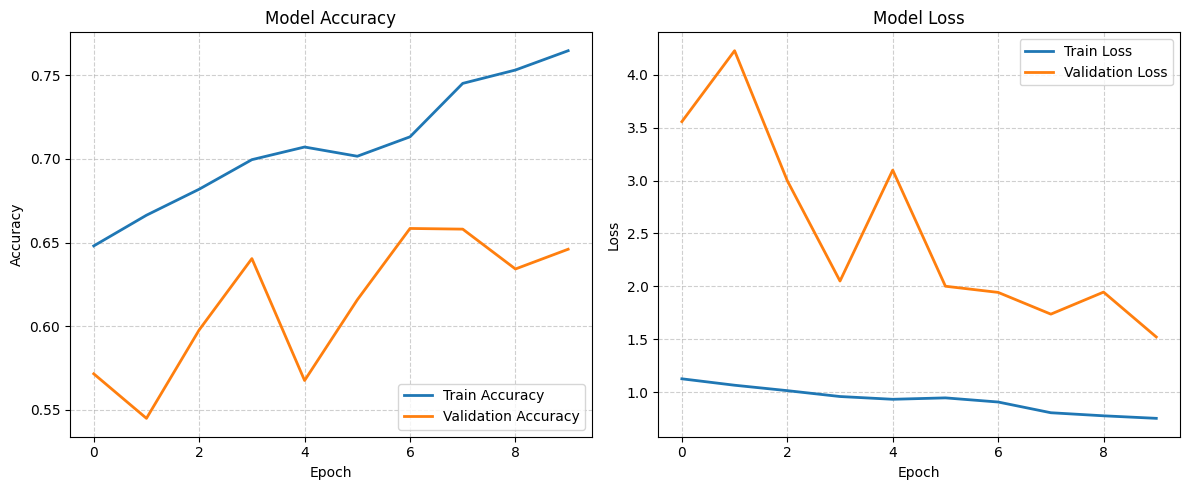

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Single Image Prediction
Predicted class: cat (71.73% confidence)
Actual class:    airplane


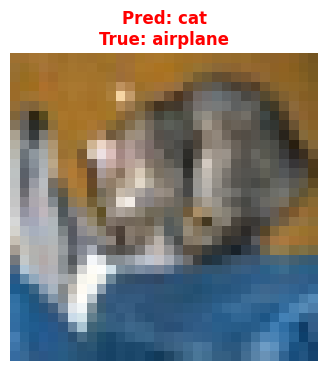

In [16]:
print("\nEvaluating Model on Test Data")

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss:     {test_loss:.4f}\n")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

#to test different images
image_index = 0

sample_image = x_test[image_index:image_index+1]


prediction_probs = model.predict(sample_image)[0]
predicted_class_idx = np.argmax(prediction_probs)

true_label = y_test[image_index]
actual_class_idx = int(true_label[0]) if isinstance(true_label, (np.ndarray, list)) else int(true_label)

#confidence percentage
print("\nSingle Image Prediction")
print(f"Predicted class: {class_names[predicted_class_idx]} ({prediction_probs[predicted_class_idx]*100:.2f}% confidence)")
print(f"Actual class:    {class_names[actual_class_idx]}")

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(sample_image[0])
plt.axis('off')

# Color the title green if correct, red if wrong
title_color = 'green' if predicted_class_idx == actual_class_idx else 'red'
plt.title(f"Pred: {class_names[predicted_class_idx]}\nTrue: {class_names[actual_class_idx]}", color=title_color, fontweight='bold')
plt.show()

Custom Loss Function 2

In [17]:
def similarity_loss(y_true, y_pred):
    y_true_labels = tf.cast(tf.argmax(y_true, axis=-1), tf.int32)

    batch_penalties = tf.gather(PENALTY_TENSOR, y_true_labels)

    expected_cost = tf.reduce_sum(batch_penalties * y_pred, axis=-1)

    standard_cce = tf.keras.losses.sparse_categorical_crossentropy(y_true_labels, y_pred)

    total_loss = standard_cce + expected_cost

    return tf.reduce_mean(total_loss)

model.compile(
    optimizer='adam',
    loss=similarity_loss,
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 282s 349ms/step - accuracy: 0.7720 - loss: 1.0844 - val_accuracy: 0.6514 - val_loss: 2.4423
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 245s 348ms/step - accuracy: 0.7849 - loss: 1.0290 - val_accuracy: 0.6874 - val_loss: 2.0224
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 245s 348ms/step - accuracy: 0.7927 - loss: 0.9922 - val_accuracy: 0.6458 - val_loss: 2.4875
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 244s 347ms/step - accuracy: 0.8028 - loss: 0.9526 - val_accuracy: 0.6468 - val_loss: 2.3803
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 245s 348ms/step - accuracy: 0.8070 - loss: 0.9278 - val_accuracy: 0.6554 - val_loss: 2.1849
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 245s 347ms/step - accuracy: 0.8088 - loss: 0.9247 - val_accuracy: 0.6596 - val_loss: 2.2082
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 247s 351ms/step - accuracy: 0.8131 - loss: 0.9136 - val_accuracy: 0.6518 - val_loss: 2.2642
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 244s 347ms/step - accuracy: 0.8233 -


Evaluating Model on Test Data
313/313 - 10s - 31ms/step - accuracy: 0.7071 - loss: 1.8071

Test accuracy: 0.7071
Final Test Accuracy: 0.7071
Final Test Loss:     1.8071



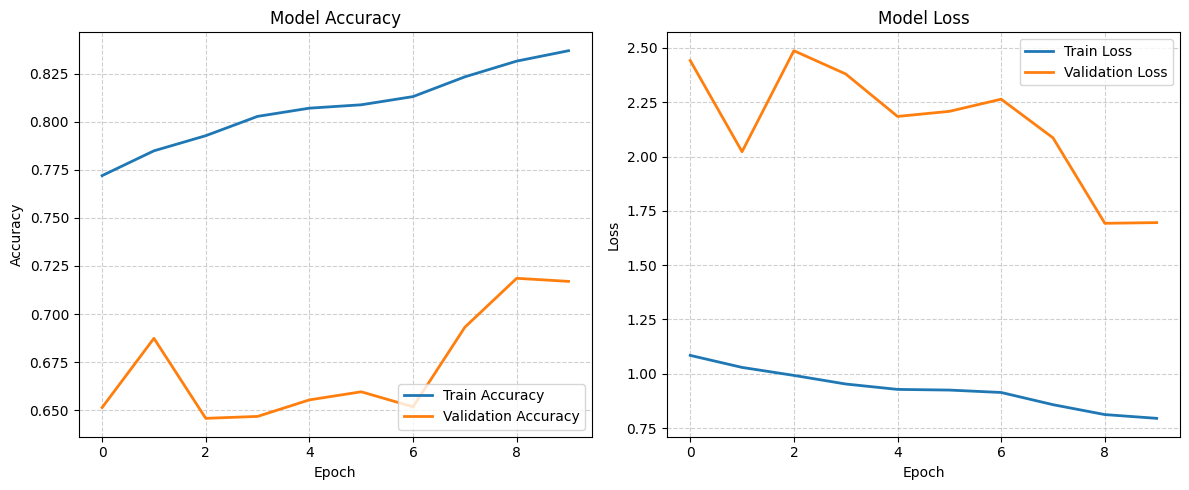

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Single Image Prediction
Predicted class: cat (98.63% confidence)
Actual class:    airplane


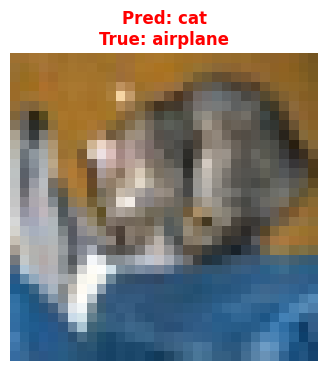

In [19]:
print("\nEvaluating Model on Test Data")

test_loss, test_acc = model.evaluate(x_test,  y_test, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss:     {test_loss:.4f}\n")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

#to test different images
image_index = 0

sample_image = x_test[image_index:image_index+1]


prediction_prob = model.predict(sample_image)[0]
predicted_class_idx = np.argmax(prediction_prob)

true_label = y_test[image_index]
actual_class_idx = int(true_label[0]) if isinstance(true_label, (np.ndarray, list)) else int(true_label)

#confidence percentage
print("\nSingle Image Prediction")
print(f"Predicted class: {class_names[predicted_class_idx]} ({prediction_prob[predicted_class_idx]*100:.2f}% confidence)")
print(f"Actual class:    {class_names[actual_class_idx]}")

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(sample_image[0])
plt.axis('off')

# Color the title green if correct, red if wrong
title_color = 'green' if predicted_class_idx == actual_class_idx else 'red'
plt.title(f"Pred: {class_names[predicted_class_idx]}\nTrue: {class_names[actual_class_idx]}", color=title_color, fontweight='bold')
plt.show()